### Transformaciones geométricas

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import supervision as sv

In [2]:
# Cargamos la imagen a procesar
img = cv.imread('dibujo.jpg')

#### 1. Traslación

\begin{equation*}
M=\begin{vmatrix}
1 &  0 & t_x \\
0 &  1 & t_y \\
\end{vmatrix}
\end{equation*}

- tx: desplazamiento en x
- ty: desplazamiento en y


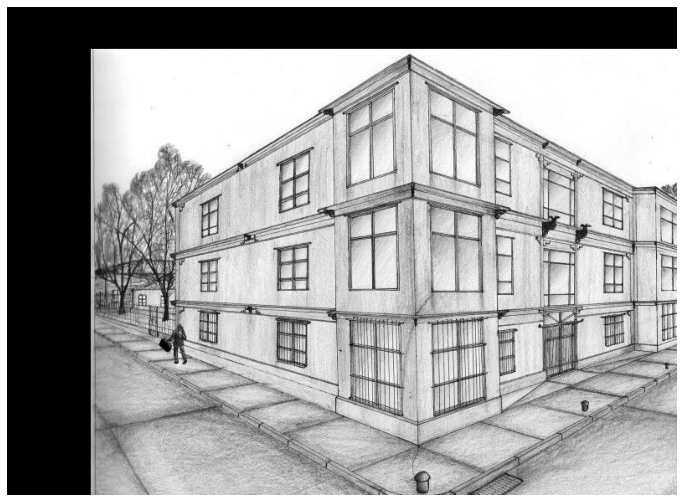

In [3]:
rows, cols, channels = img.shape

# Armamos la matriz de traslación de la imagen (tx=100, ty=50)
M = np.float32([[1, 0, 100],[0, 1, 50]])

# Aplicamos el desplazamiento (Ojo!. El tercer argumento es el tamaño de la imagen destino)
dst = cv.warpAffine(img, M, (cols, rows))

# Graficamos...
sv.plot_image(dst)

#### 2. Rotación

\begin{equation*}
M=\begin{vmatrix}
cos(\theta) &  -sin(\theta) \\
sin(\theta) &  cos(\theta) \\
\end{vmatrix}
\end{equation*}

- $\theta$: Ángulo de rotación

OpenCV permite rotar alrededor de un punto (que puede no ser el origen) y a su vez escalar la imagen

\begin{equation*}
M=\begin{vmatrix}
\alpha & \beta & (1-\alpha).centro_x - \beta.centro_y \\
-\beta & \alpha & \beta.centro_x - (1-\alpha).centro_y \\
\end{vmatrix}
\end{equation*}

Donde:

- $\alpha=escala.cos(\theta)$
- $\beta=escala.sin(\theta)$

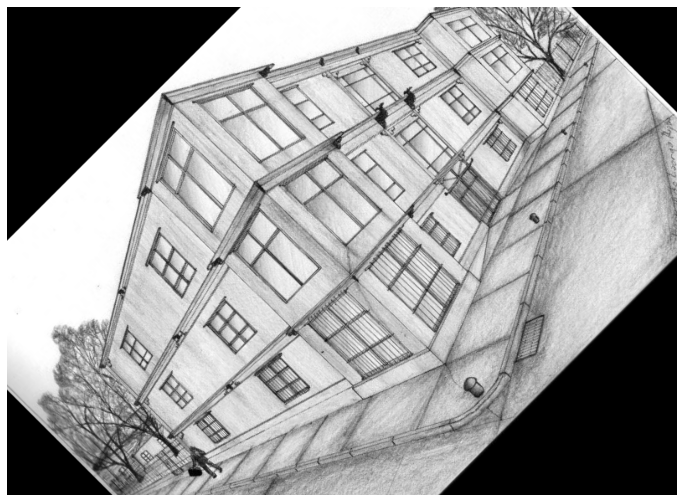

In [4]:
#rows y cols tienen los valores de filas y columnas en la imagen original
rows, cols = img.shape[:2]

# Obtenemos la matriz de rotación
#--------------------------------
# cols-1 y rows-1 son las coordenadas límite.
M = cv.getRotationMatrix2D(
    center=((cols - 1) / 2.0, (rows - 1) / 2.0), angle=45, scale=1)

# Calculamos la imagen destino
dst = cv.warpAffine(img,M,(cols,rows))

# Graficamos...
sv.plot_image(dst)

#### 3. Transformación Afín

Líneas paralelas en origen continúan paralelas en destino

Se precisan __3 puntos__ para definir la transformación

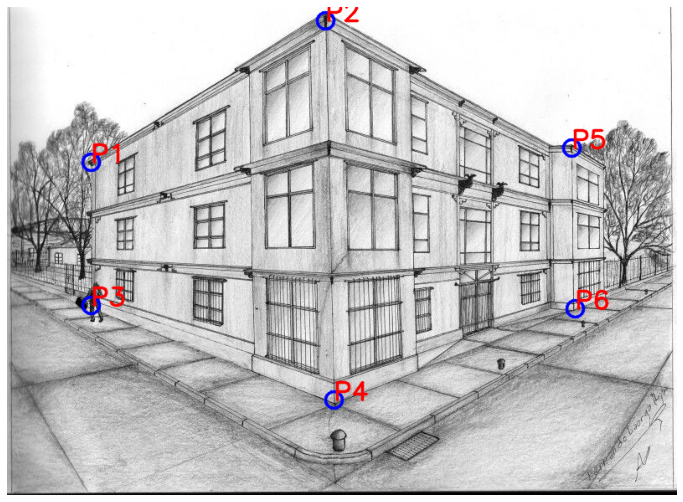

In [6]:
# Creo una copia (para hacerle anotaciones encima)
img_anota = img.copy()

# Punto 1
p1=(100, 185)
cv.circle(img_anota,p1,10,(255,0,0),2,cv.LINE_AA)
cv.putText(img_anota,'P1',p1,cv.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2,cv.LINE_AA)

# Punto 2
p2=(380, 16)
cv.circle(img_anota,p2,10,(255,0,0),2,cv.LINE_AA)
cv.putText(img_anota,'P2',p2,cv.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2,cv.LINE_AA)

# Punto 3
p3=(100, 356)
cv.circle(img_anota,p3,10,(255,0,0),2,cv.LINE_AA)
cv.putText(img_anota,'P3',p3,cv.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2,cv.LINE_AA)

# Punto 4
p4=(390, 469)
cv.circle(img_anota,p4,10,(255,0,0),2,cv.LINE_AA)
cv.putText(img_anota,'P4',p4,cv.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2,cv.LINE_AA)

# Punto 5
p5=(674, 168)
cv.circle(img_anota,p5,10,(255,0,0),2,cv.LINE_AA)
cv.putText(img_anota,'P5',p5,cv.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2,cv.LINE_AA)

# Punto 6
p6=(678, 360)
cv.circle(img_anota,p6,10,(255,0,0),2,cv.LINE_AA)
cv.putText(img_anota,'P6',p6,cv.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2,cv.LINE_AA)

# Graficamos...
sv.plot_image(img_anota)

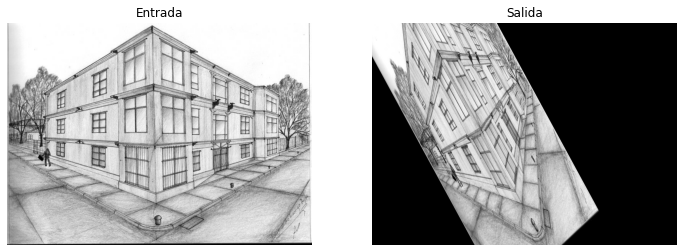

In [8]:
# Para la transformación afín necesitamos tres puntos. Usamos los puntos P1, P3 y P4

# Puntos de origen
pts1 = np.float32([[p1[0],p1[1]],[p3[0],p3[1]],[p4[0],p4[1]]])
# Puntos de destino (adonde se mapean)
pts2 = np.float32([[p1[0],p1[1]],[220, 406],[p4[0],p4[1]]])

M = cv.getAffineTransform(pts1,pts2)
dst = cv.warpAffine(img,M,(cols,rows))

sv.plot_images_grid(
    titles=['Entrada','Salida'], images=[img, dst], grid_size=(1,2))

#### 5. Transformación proyectiva

Líneas rectas en origen continúan rectas en destino

Se precisan __4 puntos__ para definir la transformación

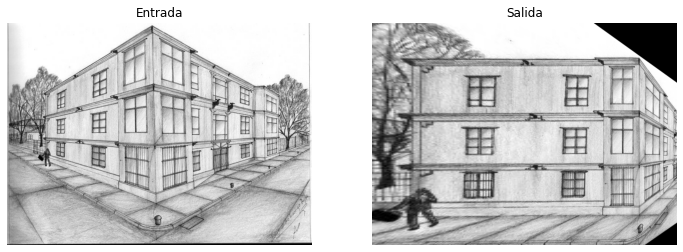

In [10]:
# Para la transformación proyectiva necesitamos cuatro puntos. Usamos los puntos P1, P2, P3 y P4

# Puntos de origen
pts1 = np.float32([[p1[0],p1[1]],[p2[0],p2[1]],[p3[0],p3[1]],[p4[0],p4[1]]])
# Puntos de destino (adonde se mapean)
pts2 = np.float32([[100,100],[700,100],[100,500],[700,500]])

M = cv.getPerspectiveTransform(pts1, pts2)
dst = cv.warpPerspective(img,M,(cols,rows))

sv.plot_images_grid(
    titles=['Entrada','Salida'], images=[img, dst], grid_size=(1,2))

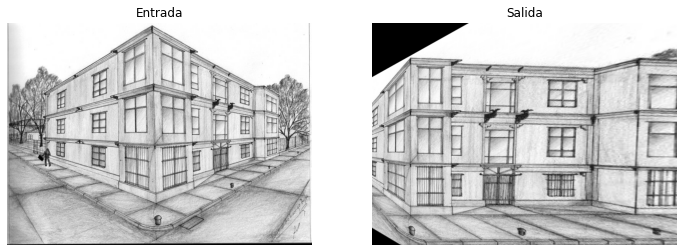

In [12]:
# ¿Qué pasa si usamos los puntos P2, P4, P5 y P6?

# Puntos de origen
pts1 = np.float32([[p2[0],p2[1]],[p4[0],p4[1]],[p5[0],p5[1]],[p6[0],p6[1]]])
# Puntos de destino (adonde se mapean)
pts2 = np.float32([[100,100],[100,500],[700,100],[700,500]])

M = cv.getPerspectiveTransform(pts1,pts2)
dst = cv.warpPerspective(img,M,(cols,rows))

sv.plot_images_grid(
    titles=['Entrada','Salida'], images=[img, dst], grid_size=(1,2))